# ⚡ End-to-End Electric Vehicle (EV) Energy Rating Prediction

**Goal:** Predict the `Energy_Rating` of an EV (`Very Efficient`, `Efficient`, `Average`, `High Consumption`) from its technical specifications.

---
**Pipeline Overview:**
1. 📦 Library Setup
2. 📊 Data Loading & First Look
3. 🔍 Exploratory Data Analysis (EDA)
4. 🛠️ Feature Engineering & Preprocessing
5. 🤖 Model Training (Logistic Regression, Random Forest, XGBoost, SVM)
6. 📈 Model Evaluation & Comparison
7. 🔎 Feature Importance
8. 🧪 Hyperparameter Tuning
9. 🏆 Final Model & Predictions
10. 💾 Save & Export

---
## 1. 📦 Library Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Run: pip install xgboost")

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

# Persistence
import joblib

# Style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
SEED = 42

---
## 2. 📊 Data Loading & First Look

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/organizations/ailearner-researchlab/ai-learner-tech-ev-prices-and-specs-2026/AI_Learner_EV_Dataset_Pro.csv')

print(f"Dataset shape : {df.shape}  ({df.shape[0]} EVs × {df.shape[1]} features)")
df.head()

Dataset shape : (103, 16)  (103 EVs × 16 features)


,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro,Price_Per_Range,Energy_Rating
0,Audi,e-tron 50 quattro,6.8,190,280,231,450,Yes,AWD,Type 2 CCS,SUV,E,5,67358,240.56,High Consumption
1,Tesla,Cybertruck Dual Motor,5.0,190,460,261,710,Yes,AWD,Type 2 CCS,Pickup,N,6,55000,119.57,High Consumption
2,Nissan,Ariya 87kWh,7.6,160,440,198,520,Yes,FWD,Type 2 CCS,Hatchback,C,5,50000,113.64,Average
3,Porsche,Taycan 4S,4.0,250,365,195,730,Yes,AWD,Type 2 CCS,Sedan,F,4,102945,282.04,Average
4,Audi,e-tron Sportback 55 quattro,5.7,200,380,228,610,Yes,AWD,Type 2 CCS,SUV,E,5,81639,214.84,High Consumption


In [3]:
print("── Column types & non-null counts ──")
df.info()

── Column types & non-null counts ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            103 non-null    object 
 1   Model            103 non-null    object 
 2   AccelSec         103 non-null    float64
 3   TopSpeed_KmH     103 non-null    int64  
 4   Range_Km         103 non-null    int64  
 5   Efficiency_WhKm  103 non-null    int64  
 6   FastCharge_KmH   103 non-null    object 
 7   RapidCharge      103 non-null    object 
 8   PowerTrain       103 non-null    object 
 9   PlugType         103 non-null    object 
 10  BodyStyle        103 non-null    object 
 11  Segment          103 non-null    object 
 12  Seats            103 non-null    int64  
 13  PriceEuro        103 non-null    int64  
 14  Price_Per_Range  103 non-null    float64
 15  Energy_Rating    103 non-null    object 
dtypes: float64(2), int64(5), 

In [4]:
print("── Numeric summary ──")
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std','max'])

── Numeric summary ──


,count,mean,std,min,25%,50%,75%,max
AccelSec,103.000000,7.396117,3.017430,2.100000,5.100000,7.300000,9.000000,22.400000
TopSpeed_KmH,103.000000,179.194175,43.573030,123.000000,150.000000,160.000000,200.000000,410.000000
Range_Km,103.000000,338.786408,126.014444,95.000000,250.000000,340.000000,400.000000,970.000000
Efficiency_WhKm,103.000000,189.165049,29.566839,104.000000,168.000000,180.000000,203.000000,273.000000
Seats,103.000000,4.883495,0.795834,2.000000,5.000000,5.000000,5.000000,7.000000
PriceEuro,103.000000,55811.563107,34134.665280,20129.000000,34429.500000,45000.000000,65000.000000,215000.000000
Price_Per_Range,103.000000,164.604466,66.793056,93.040000,116.285000,144.440000,189.845000,482.080000


In [5]:
print("── Missing values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "🎉 No missing values found!")

── Missing values ──
🎉 No missing values found!


In [6]:
print("── Target class distribution ──")
print(df['Energy_Rating'].value_counts())
print(f"\nClass balance ratio: {df['Energy_Rating'].value_counts().max() / df['Energy_Rating'].value_counts().min():.2f}x")

── Target class distribution ──
Energy_Rating
Very Efficient      30
High Consumption    26
Average             25
Efficient           22
Name: count, dtype: int64

Class balance ratio: 1.36x


---
## 3. 🔍 Exploratory Data Analysis (EDA)

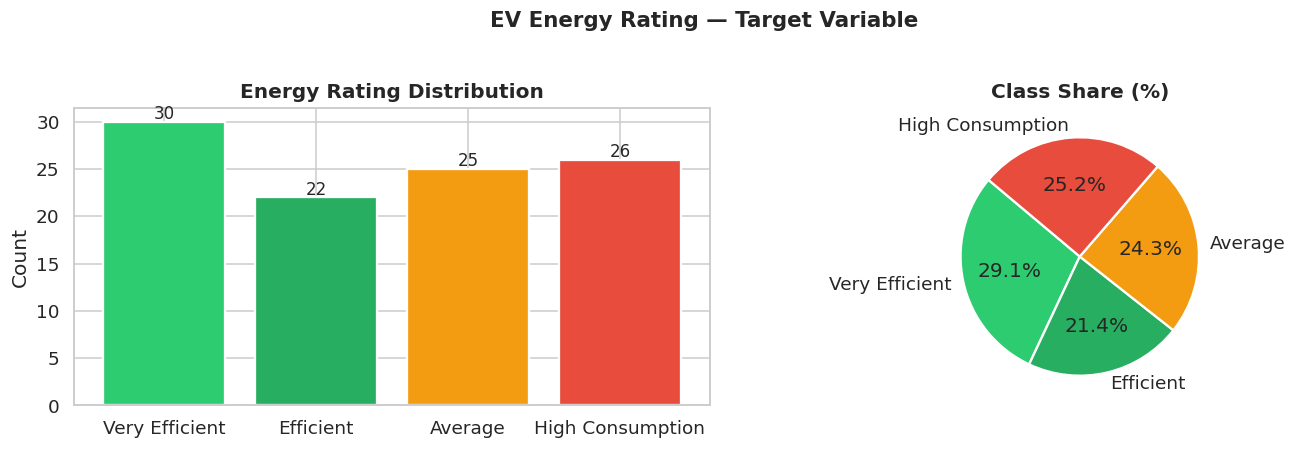

In [7]:
# ── Target distribution ───────────────────────────────────────────────────────
ORDER = ['Very Efficient', 'Efficient', 'Average', 'High Consumption']
PALETTE = {'Very Efficient': '#2ecc71', 'Efficient': '#27ae60',
           'Average': '#f39c12', 'High Consumption': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['Energy_Rating'].value_counts().reindex(ORDER)
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[k] for k in counts.index], edgecolor='white', linewidth=1.5)
axes[0].set_title('Energy Rating Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for p, v in zip(axes[0].patches, counts.values):
    axes[0].text(p.get_x() + p.get_width()/2, v + 0.3, str(v), ha='center', fontsize=11)

pct = counts / counts.sum() * 100
axes[1].pie(pct.values, labels=pct.index, autopct='%1.1f%%',
            colors=[PALETTE[k] for k in pct.index], startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Share (%)', fontweight='bold')

plt.suptitle('EV Energy Rating — Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

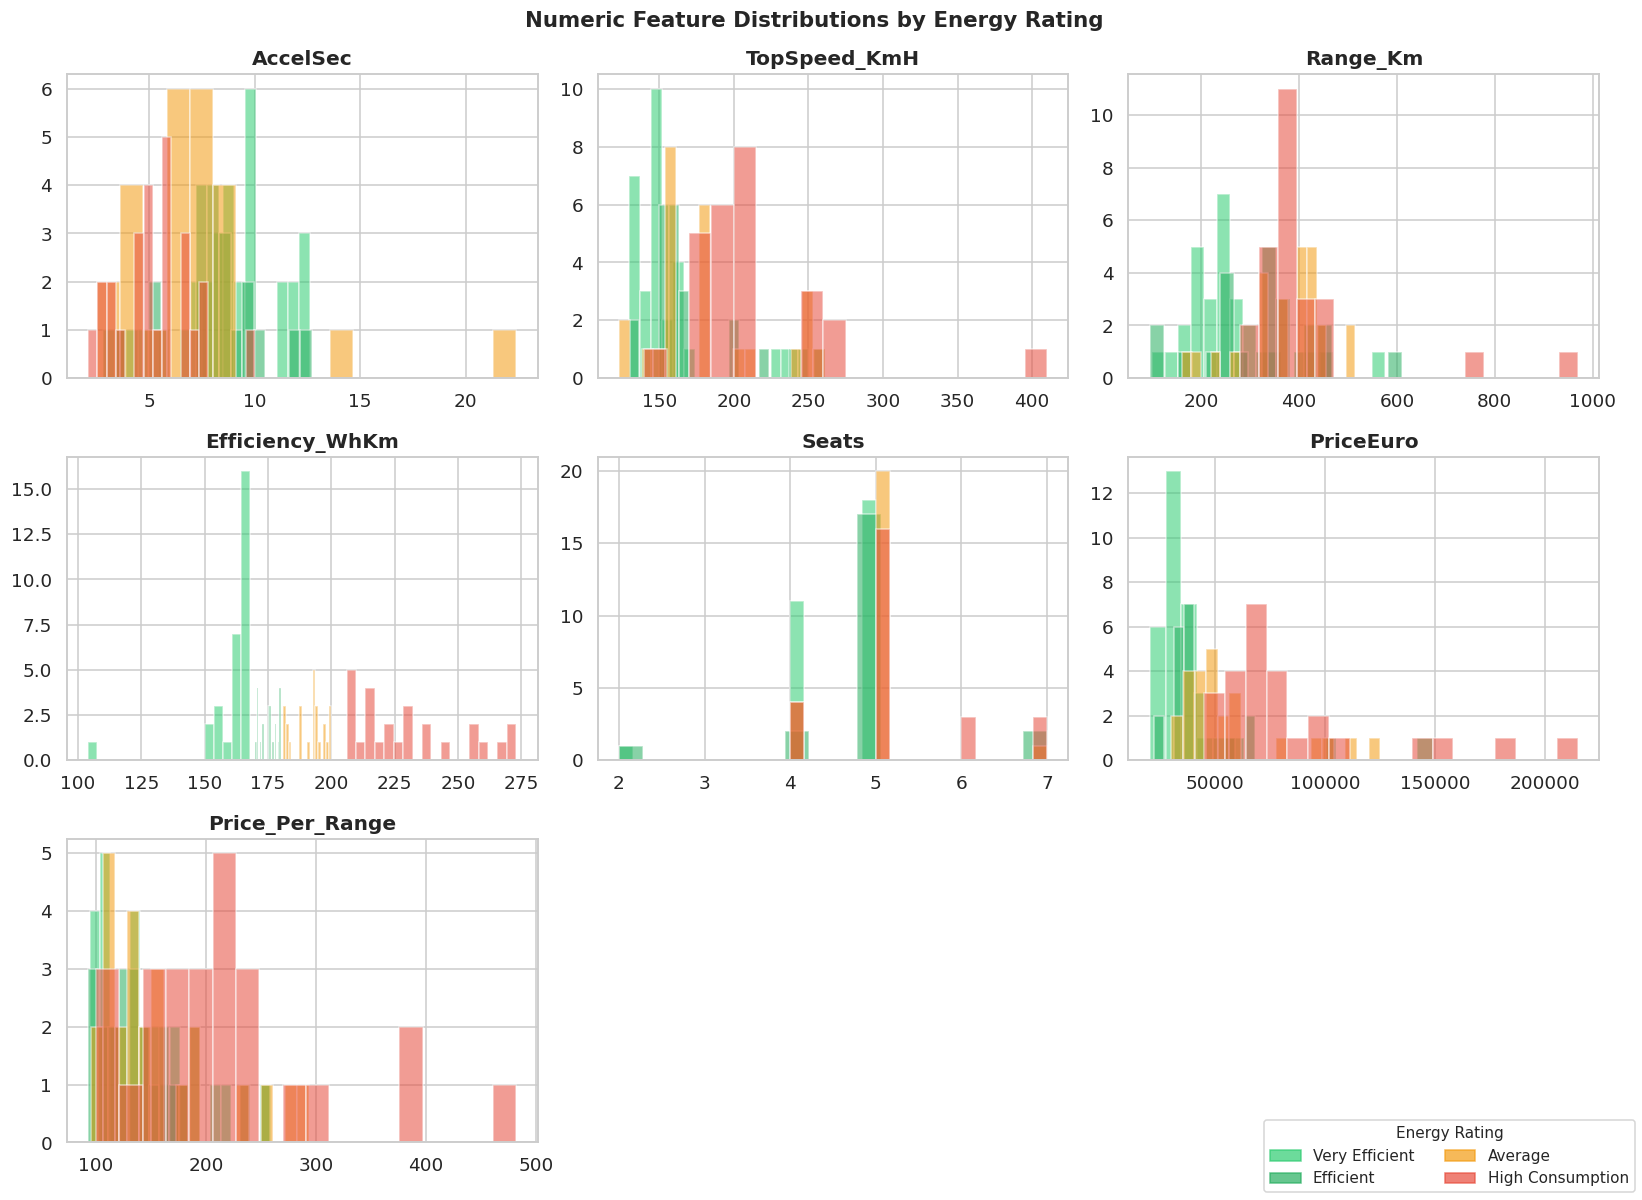

In [8]:
# ── Numeric feature distributions ────────────────────────────────────────────
num_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for rating, color in PALETTE.items():
        subset = df[df['Energy_Rating'] == rating][col]
        axes[i].hist(subset, bins=18, alpha=0.55, label=rating, color=color, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

# Hide unused subplot
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

handles = [plt.Rectangle((0,0),1,1, color=PALETTE[r], alpha=0.7) for r in ORDER]
fig.legend(handles, ORDER, loc='lower right', ncol=2, fontsize=10,
           title='Energy Rating', title_fontsize=10)
fig.suptitle('Numeric Feature Distributions by Energy Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

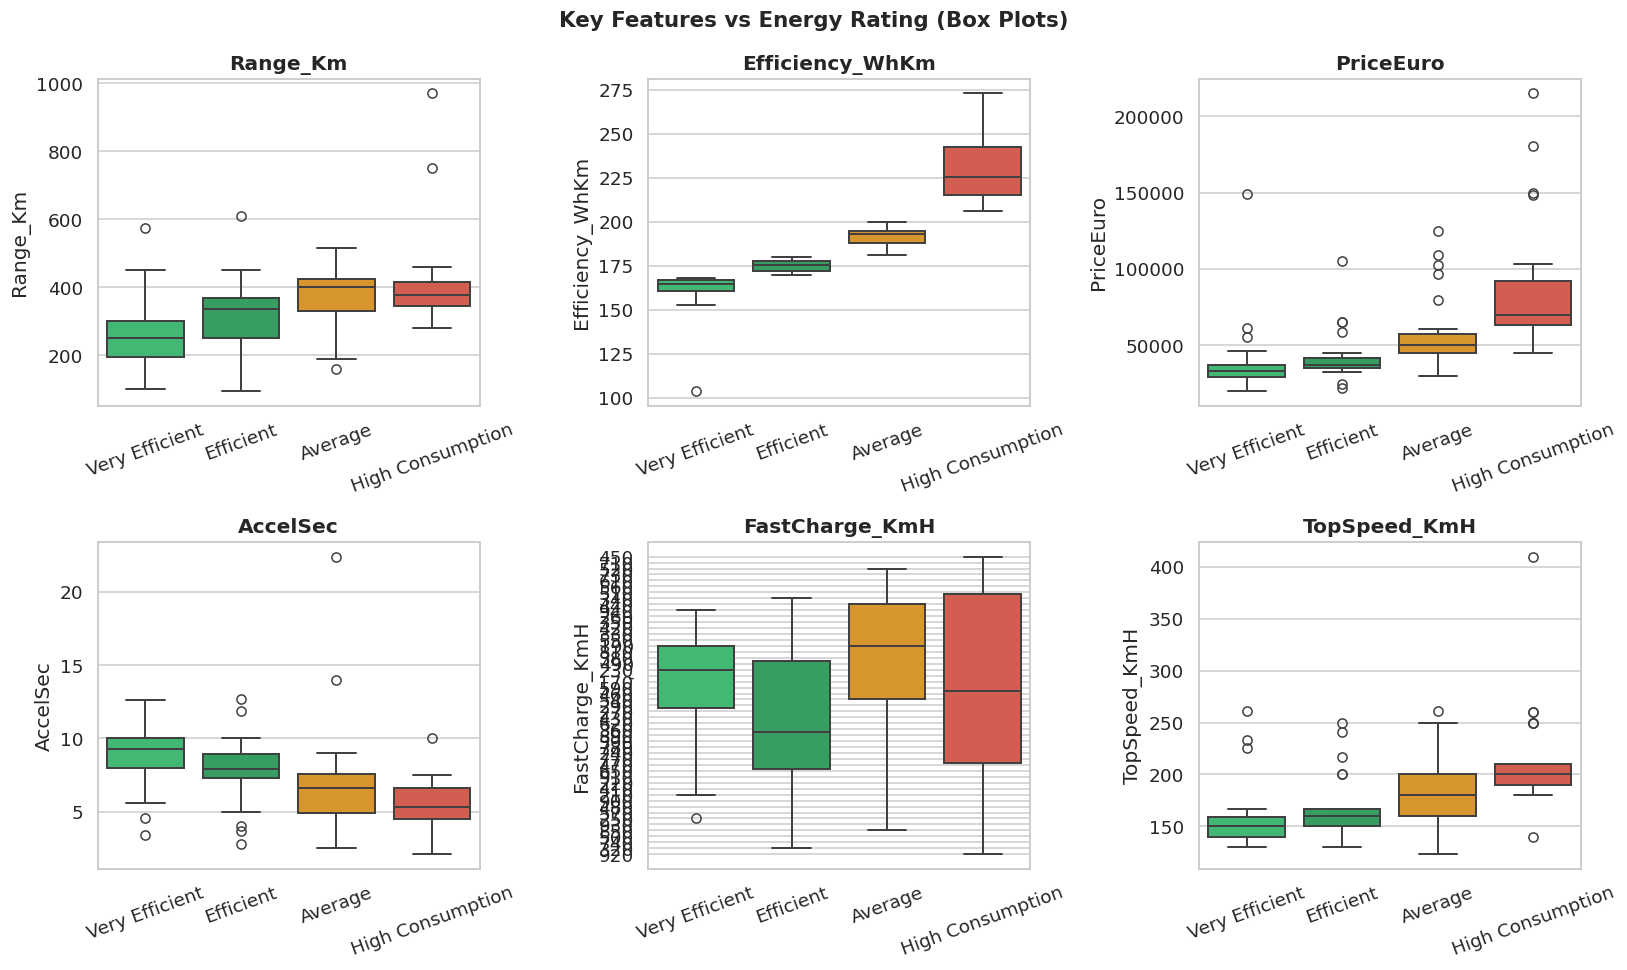

In [9]:
# ── Box plots: key features vs. Energy Rating ─────────────────────────────────
key_features = ['Range_Km', 'Efficiency_WhKm', 'PriceEuro', 'AccelSec', 'FastCharge_KmH', 'TopSpeed_KmH']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    sns.boxplot(
        data=df, x='Energy_Rating', y=feat, order=ORDER,
        palette=PALETTE, ax=axes[i], linewidth=1.3
    )
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)

fig.suptitle('Key Features vs Energy Rating (Box Plots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

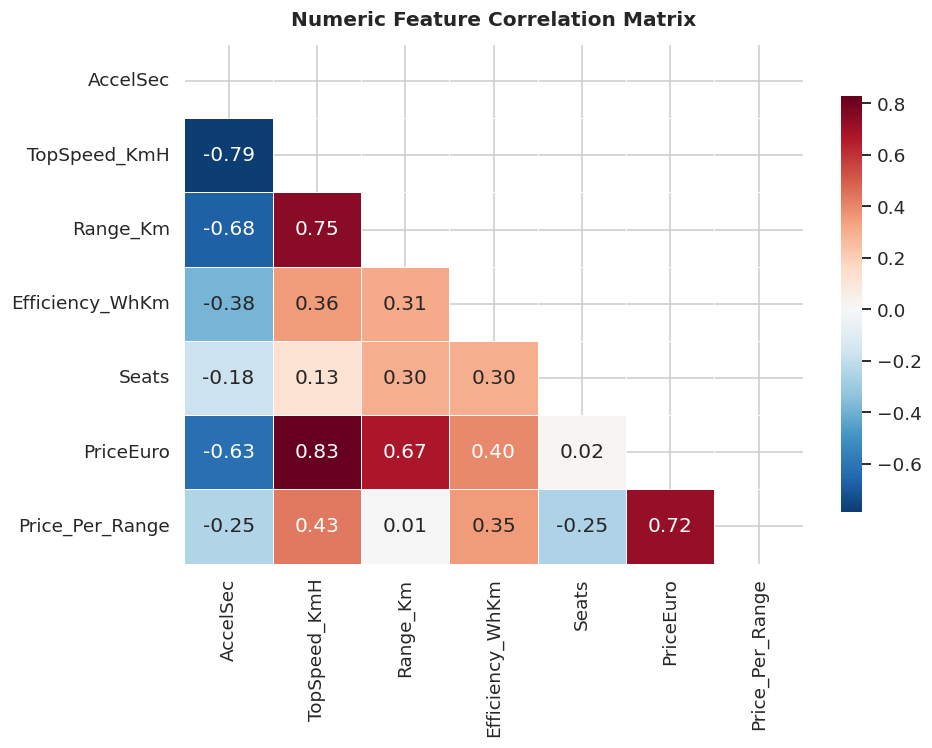

In [10]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Numeric Feature Correlation Matrix', fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

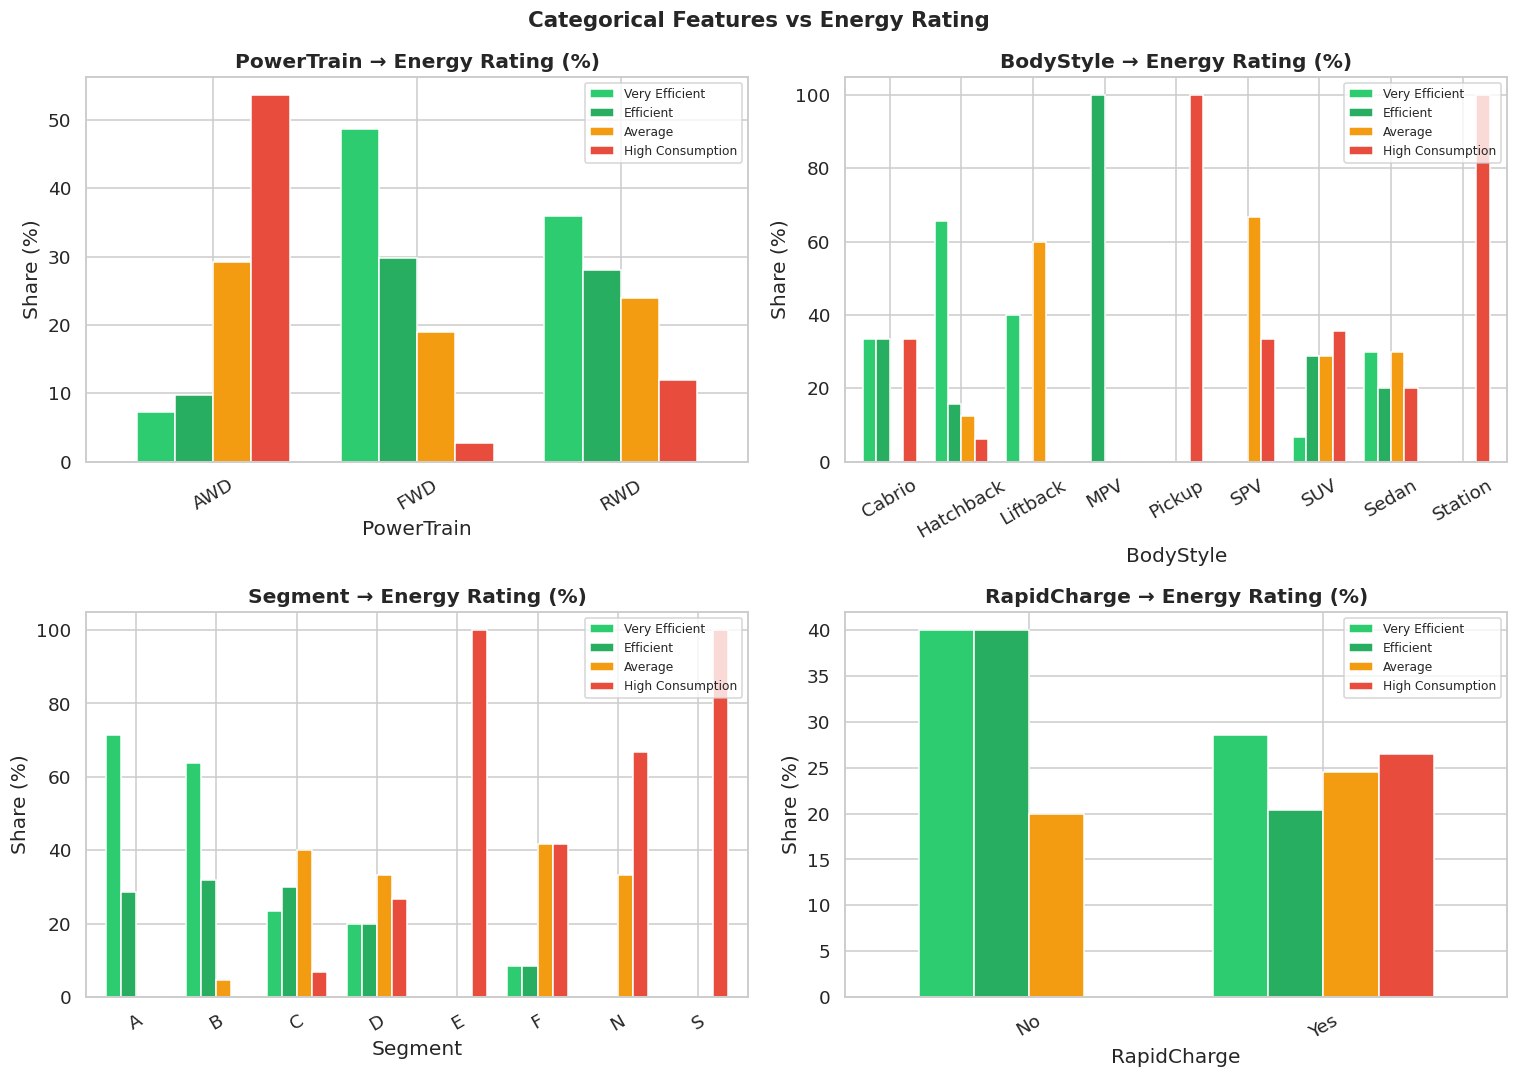

In [11]:
# ── Categorical feature analysis ──────────────────────────────────────────────
cat_cols = ['PowerTrain', 'BodyStyle', 'Segment', 'RapidCharge']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Energy_Rating'], normalize='index') * 100
    ct = ct.reindex(columns=[c for c in ORDER if c in ct.columns])
    ct.plot(kind='bar', ax=axes[i], color=[PALETTE[c] for c in ct.columns],
            edgecolor='white', width=0.75)
    axes[i].set_title(f'{col} → Energy Rating (%)', fontweight='bold')
    axes[i].set_ylabel('Share (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=8, loc='upper right')

fig.suptitle('Categorical Features vs Energy Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. 🛠️ Feature Engineering & Preprocessing

In [12]:
# ── New engineered features ────────────────────────────────────────────────────
df_ml = df.copy()
# Fix dtypes
df_ml['FastCharge_KmH'] = pd.to_numeric(df_ml['FastCharge_KmH'], errors='coerce').fillna(0)

# 1. Speed-to-Range ratio
df_ml['Speed_Range_Ratio']  = df_ml['TopSpeed_KmH'] / df_ml['Range_Km']

# 2. Charge efficiency (km gained per charge speed unit)
df_ml['Charge_Efficiency']  = df_ml['FastCharge_KmH'] / df_ml['Efficiency_WhKm']

# 3. Value score (range per euro)
df_ml['Value_Score']        = df_ml['Range_Km'] / df_ml['PriceEuro'] * 1000

# 4. Performance index  (lower accel + higher top speed = more performant)
df_ml['Perf_Index']         = df_ml['TopSpeed_KmH'] / df_ml['AccelSec']

print("✅ Engineered 4 new features:")
print("   Speed_Range_Ratio | Charge_Efficiency | Value_Score | Perf_Index")
df_ml[['Speed_Range_Ratio','Charge_Efficiency','Value_Score','Perf_Index']].describe().T

✅ Engineered 4 new features:
   Speed_Range_Ratio | Charge_Efficiency | Value_Score | Perf_Index


,count,mean,std,min,25%,50%,75%,max
Speed_Range_Ratio,103.0,0.576216,0.185233,0.260870,0.457534,0.547945,0.645718,1.368421
Charge_Efficiency,103.0,2.297908,1.176952,0.000000,1.447044,2.111111,2.797927,5.838509
Value_Score,103.0,6.826372,2.068100,2.074333,5.267528,6.923077,8.600000,10.748485
Perf_Index,103.0,32.031014,26.466209,5.803571,16.666667,21.506849,37.367347,195.238095


In [13]:
# ── Encode target ─────────────────────────────────────────────────────────────
TARGET = 'Energy_Rating'
TARGET_ORDER = ['Very Efficient', 'Efficient', 'Average', 'High Consumption']

le = LabelEncoder()
le.fit(TARGET_ORDER)
df_ml['target'] = le.transform(df_ml[TARGET])

print("Label mapping:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {code}  →  {cls}")

Label mapping:
  0  →  Average
  1  →  Efficient
  2  →  High Consumption
  3  →  Very Efficient


In [14]:
# ── Define feature matrix ──────────────────────────────────────────────────────
DROP_COLS = ['Brand', 'Model', TARGET, 'target']   # non-predictive / target

NUMERIC_FEATURES = [
    'AccelSec', 'TopSpeed_KmH', 'Range_Km', 'Efficiency_WhKm',
    'FastCharge_KmH', 'Seats', 'PriceEuro', 'Price_Per_Range',
    'Speed_Range_Ratio', 'Charge_Efficiency', 'Value_Score', 'Perf_Index'
]

BINARY_FEATURES = ['RapidCharge']   # Yes / No

NOMINAL_FEATURES = ['PowerTrain', 'PlugType', 'BodyStyle', 'Segment']

X = df_ml[NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES]
y = df_ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train : {X_train.shape}   |   Test : {X_test.shape}")
print(f"Target classes: {list(le.classes_)}")

Train : (82, 17)   |   Test : (21, 17)
Target classes: [np.str_('Average'), np.str_('Efficient'), np.str_('High Consumption'), np.str_('Very Efficient')]


In [15]:
# ── ColumnTransformer ─────────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())   # Yes→1, No→0
])

nominal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('bin', binary_transformer,  BINARY_FEATURES),
    ('nom', nominal_transformer, NOMINAL_FEATURES),
])

print("✅ Preprocessor built:")
print(f"   {len(NUMERIC_FEATURES)} numeric | {len(BINARY_FEATURES)} binary | {len(NOMINAL_FEATURES)} nominal")

✅ Preprocessor built:
   12 numeric | 1 binary | 4 nominal


---
## 5. 🤖 Model Training

In [16]:
# ── Define models ──────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=SEED),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, use_label_encoder=False,
        eval_metric='mlogloss', random_state=SEED
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor), ('clf', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                                scoring='accuracy', n_jobs=-1)
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))

    results[name] = {
        'pipeline':  pipe,
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'test_acc':  test_acc
    }
    print(f"{name:<25}  CV={cv_scores.mean():.4f} (±{cv_scores.std():.4f})  Test={test_acc:.4f}")

Logistic Regression        CV=0.7199 (±0.0600)  Test=0.6667
KNN                        CV=0.5868 (±0.0991)  Test=0.7143
SVM                        CV=0.6081 (±0.0903)  Test=0.5714
Random Forest              CV=0.8419 (±0.0622)  Test=0.9524
Gradient Boosting          CV=1.0000 (±0.0000)  Test=1.0000


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:00:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:00:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:00:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:00:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost                    CV=0.9875 (±0.0250)  Test=1.0000


---
## 6. 📈 Model Evaluation & Comparison

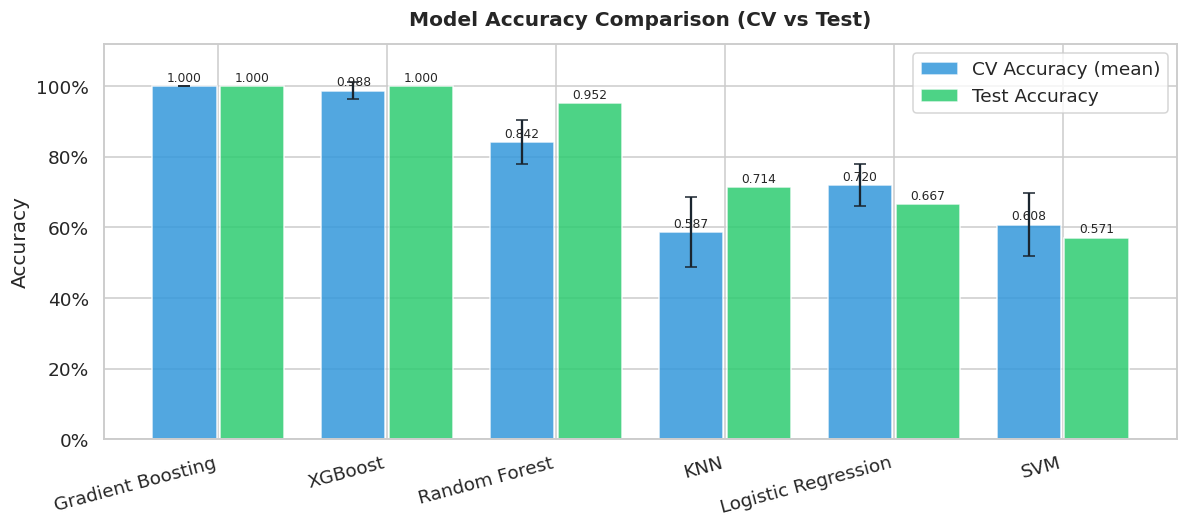

              Model   CV Acc   CV Std  Test Acc
  Gradient Boosting 1.000000 0.000000  1.000000
            XGBoost 0.987500 0.025000  1.000000
      Random Forest 0.841912 0.062218  0.952381
                KNN 0.586765 0.099131  0.714286
Logistic Regression 0.719853 0.059979  0.666667
                SVM 0.608088 0.090283  0.571429


In [17]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
res_df = pd.DataFrame({
    'Model':    list(results.keys()),
    'CV Acc':   [v['cv_mean']  for v in results.values()],
    'CV Std':   [v['cv_std']   for v in results.values()],
    'Test Acc': [v['test_acc'] for v in results.values()],
}).sort_values('Test Acc', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(res_df))
bars1 = ax.bar(x - 0.2, res_df['CV Acc'],  0.38, label='CV Accuracy (mean)',
               color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + 0.2, res_df['Test Acc'], 0.38, label='Test Accuracy',
               color='#2ecc71', alpha=0.85, edgecolor='white')

# Error bars for CV std
ax.errorbar(x - 0.2, res_df['CV Acc'], yerr=res_df['CV Std'],
            fmt='none', color='#1a252f', capsize=4, linewidth=1.5)

for bar in [*bars1, *bars2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(res_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title('Model Accuracy Comparison (CV vs Test)', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.show()

print(res_df[['Model','CV Acc','CV Std','Test Acc']].to_string(index=False))

In [18]:
# ── Best model detailed report ─────────────────────────────────────────────────
BEST_MODEL_NAME = res_df.iloc[0]['Model']
best_pipe = results[BEST_MODEL_NAME]['pipeline']
y_pred    = best_pipe.predict(X_test)

print(f"🏆 Best model: {BEST_MODEL_NAME}")
print(f"   Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

🏆 Best model: Gradient Boosting
   Test Accuracy: 1.0000

Classification Report:
                  precision    recall  f1-score   support

         Average       1.00      1.00      1.00         5
       Efficient       1.00      1.00      1.00         5
High Consumption       1.00      1.00      1.00         5
  Very Efficient       1.00      1.00      1.00         6

        accuracy                           1.00        21
       macro avg       1.00      1.00      1.00        21
    weighted avg       1.00      1.00      1.00        21



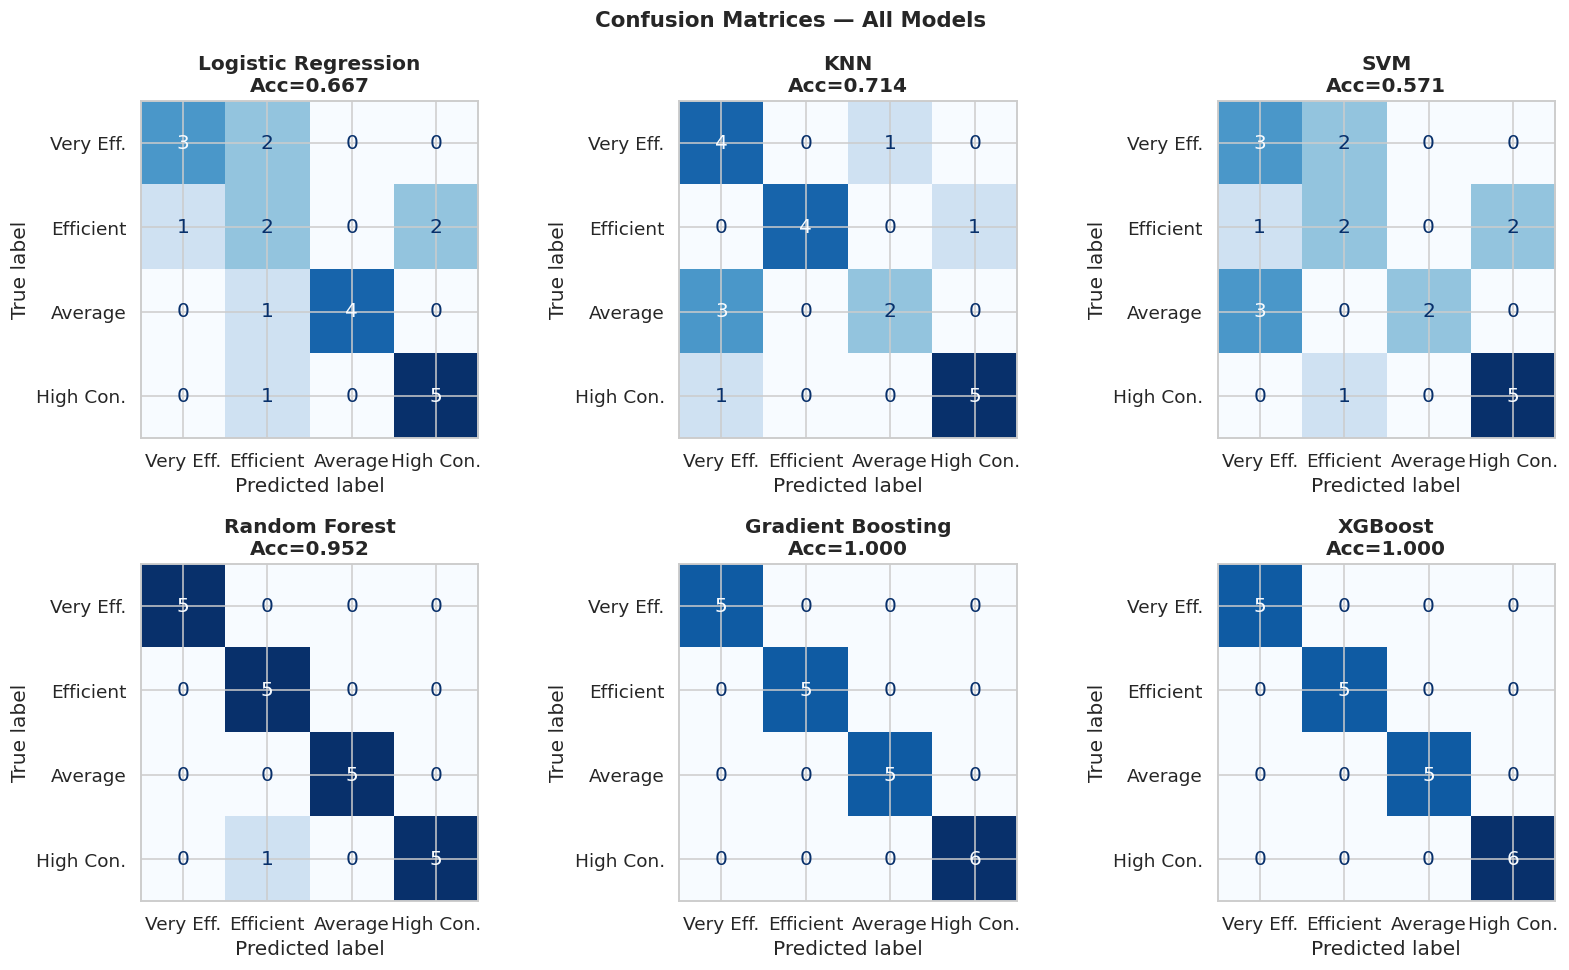

In [19]:
# ── Confusion matrices: all models ────────────────────────────────────────────
n_models = len(results)
ncols    = 3
nrows    = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4.5))
axes = axes.flatten()

for i, (name, info) in enumerate(results.items()):
    preds = info['pipeline'].predict(X_test)
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=[
        'Very Eff.', 'Efficient', 'Average', 'High Con.'
    ])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{name}\nAcc={info['test_acc']:.3f}", fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. 🔎 Feature Importance

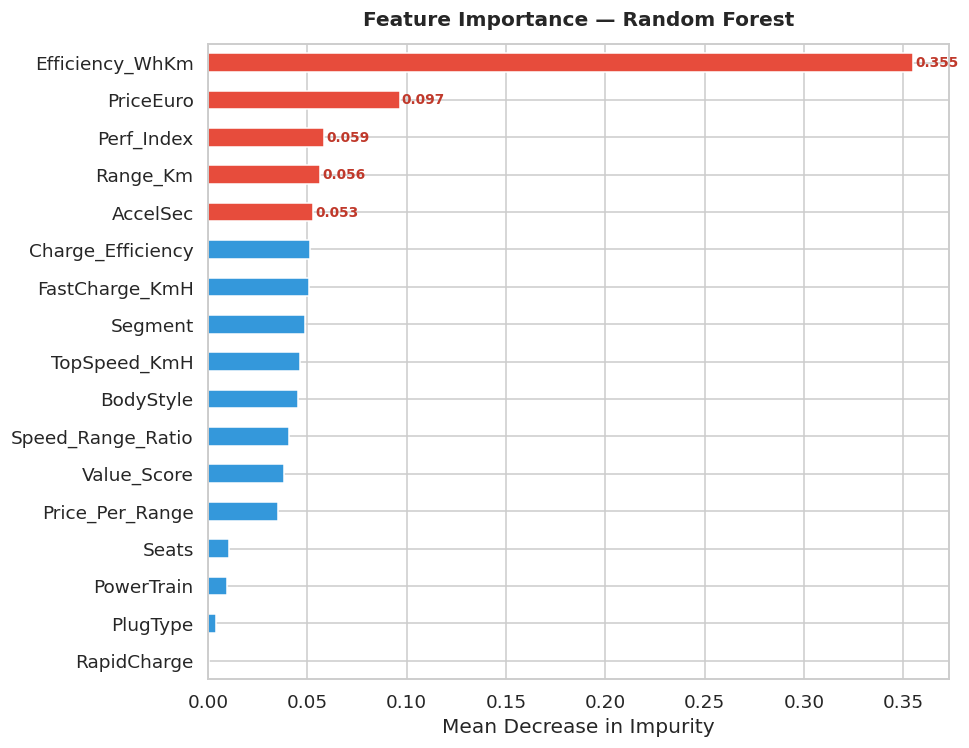

Top 5 most important features:
Efficiency_WhKm    0.355119
PriceEuro          0.096531
Perf_Index         0.058577
Range_Km           0.056436
AccelSec           0.053023


In [20]:
# ── Random Forest feature importance ──────────────────────────────────────────
rf_pipe = results['Random Forest']['pipeline']
rf_clf  = rf_pipe.named_steps['clf']

feature_names = NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES
importances   = pd.Series(rf_clf.feature_importances_, index=feature_names)\
                  .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if i >= len(importances)-5 else '#3498db'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontweight='bold', pad=12)
ax.set_xlabel('Mean Decrease in Impurity')

# Annotate top-5
for i, (val, name) in enumerate(zip(importances.values[-5:],
                                     importances.index[-5:])):
    ax.text(val + 0.001, len(importances)-5+i, f'{val:.3f}',
            va='center', fontsize=9, color='#c0392b', fontweight='bold')

plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).to_string())

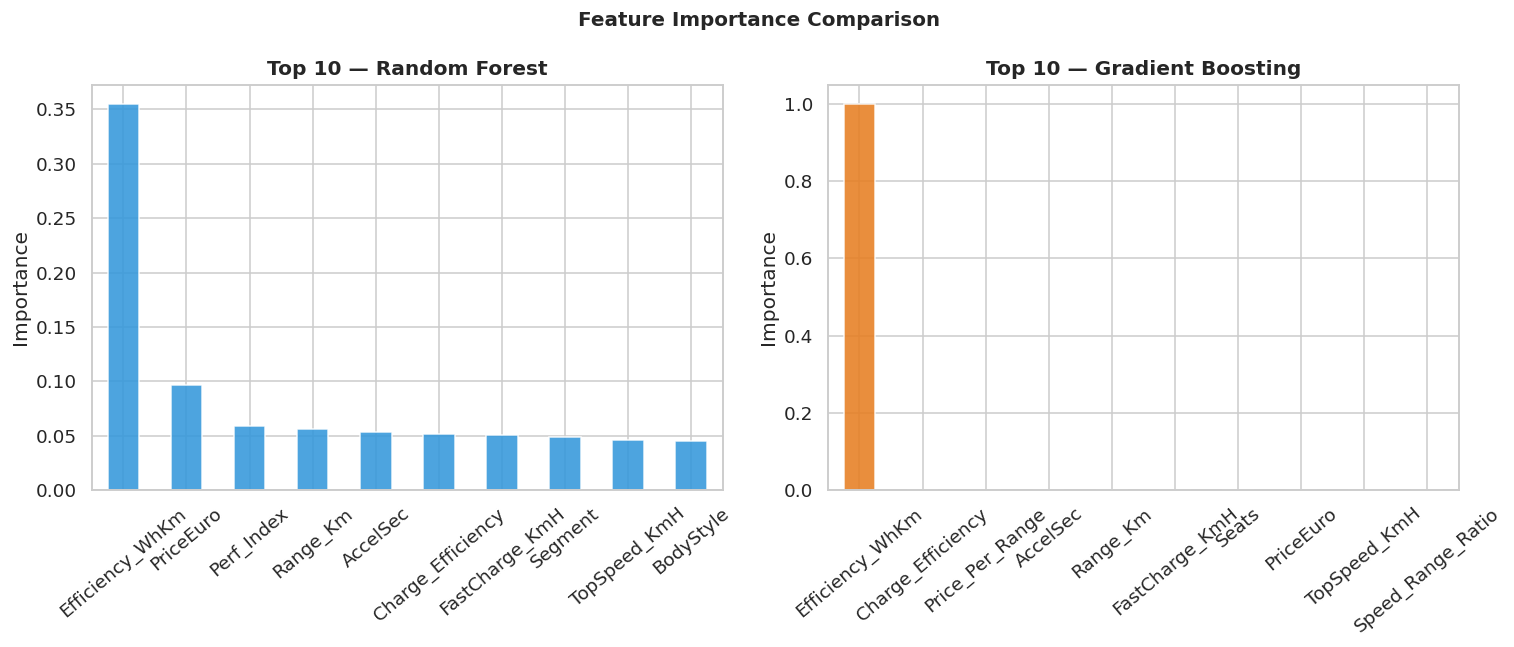

In [21]:
# ── Gradient Boosting feature importance (comparison) ────────────────────────
gb_pipe = results['Gradient Boosting']['pipeline']
gb_clf  = gb_pipe.named_steps['clf']

gb_imp = pd.Series(gb_clf.feature_importances_, index=feature_names)\
           .sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RF
importances.sort_values(ascending=False).head(10).plot(
    kind='bar', ax=axes[0], color='#3498db', edgecolor='white', alpha=0.88
)
axes[0].set_title('Top 10 — Random Forest', fontweight='bold')
axes[0].set_ylabel('Importance')
axes[0].tick_params(axis='x', rotation=40)

# GB
gb_imp.head(10).plot(
    kind='bar', ax=axes[1], color='#e67e22', edgecolor='white', alpha=0.88
)
axes[1].set_title('Top 10 — Gradient Boosting', fontweight='bold')
axes[1].set_ylabel('Importance')
axes[1].tick_params(axis='x', rotation=40)

fig.suptitle('Feature Importance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. 🧪 Hyperparameter Tuning (Best Model)

In [22]:
# ── Grid search on Random Forest ──────────────────────────────────────────────
param_grid = {
    'clf__n_estimators':      [100, 200, 300],
    'clf__max_depth':         [None, 5, 10, 15],
    'clf__min_samples_split': [2, 5, 10],
    'clf__max_features':      ['sqrt', 'log2'],
}

tune_pipe = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(random_state=SEED))
])

grid_search = GridSearchCV(
    tune_pipe, param_grid,
    cv=cv, scoring='accuracy',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print("🎯 Best Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"   {k}: {v}")
print(f"\nBest CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Tuned Test Acc   : {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")

🎯 Best Parameters:
   clf__max_depth: None
   clf__max_features: sqrt
   clf__min_samples_split: 2
   clf__n_estimators: 300

Best CV Accuracy : 0.8537
Tuned Test Acc   : 0.9524


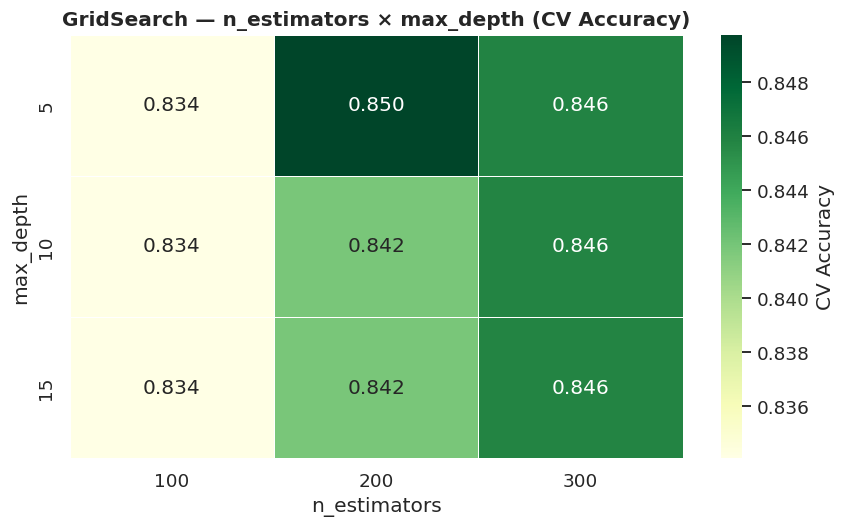

In [23]:
# ── Tuning result: n_estimators vs max_depth ──────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)

# Pivot for n_estimators vs max_depth
pivot = cv_results.pivot_table(
    values='mean_test_score',
    index='param_clf__max_depth',
    columns='param_clf__n_estimators'
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot, annot=True, fmt='.3f', cmap='YlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'CV Accuracy'}
)
ax.set_title('GridSearch — n_estimators × max_depth (CV Accuracy)', fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

---
## 9. 🏆 Final Model & Predictions

In [24]:
# ── Finalise best tuned model ─────────────────────────────────────────────────
final_model = grid_search.best_estimator_

y_final_pred = final_model.predict(X_test)
final_acc    = accuracy_score(y_test, y_final_pred)

print(f"✅ Final Model: Random Forest (Tuned)")
print(f"   Test Accuracy: {final_acc:.4f}  ({final_acc*100:.1f}%)\n")
print(classification_report(y_test, y_final_pred, target_names=le.classes_))

✅ Final Model: Random Forest (Tuned)
   Test Accuracy: 0.9524  (95.2%)

                  precision    recall  f1-score   support

         Average       1.00      1.00      1.00         5
       Efficient       0.83      1.00      0.91         5
High Consumption       1.00      1.00      1.00         5
  Very Efficient       1.00      0.83      0.91         6

        accuracy                           0.95        21
       macro avg       0.96      0.96      0.95        21
    weighted avg       0.96      0.95      0.95        21



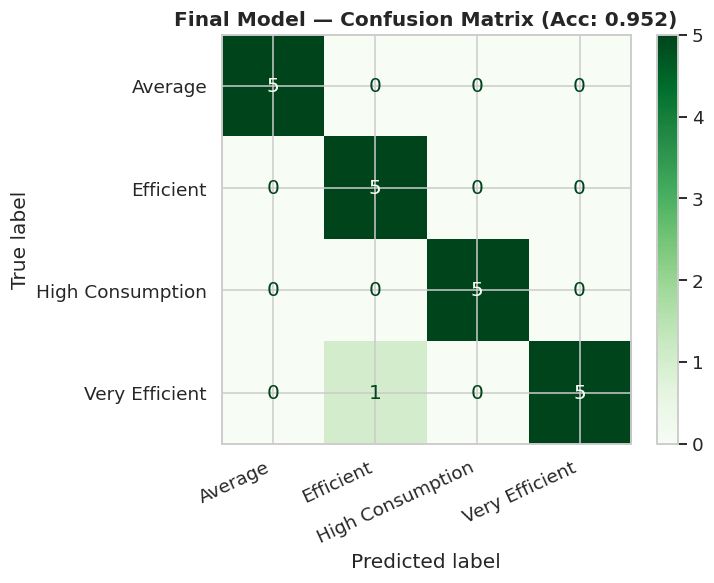

In [25]:
# ── Final confusion matrix ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))
cm = confusion_matrix(y_test, y_final_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=ax, colorbar=True, cmap='Greens'
)
ax.set_title(f'Final Model — Confusion Matrix (Acc: {final_acc:.3f})', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [26]:
# ── Predict on new (hypothetical) EVs ────────────────────────────────────────
new_evs = pd.DataFrame({
    'AccelSec':         [4.5,   9.0,   6.2],
    'TopSpeed_KmH':     [250,   150,   180],
    'Range_Km':         [600,   300,   450],
    'Efficiency_WhKm':  [160,   250,   190],
    'FastCharge_KmH':   [800,   300,   600],
    'Seats':            [5,     5,     7],
    'PriceEuro':        [120000,28000, 55000],
    'Price_Per_Range':  [200.0, 93.3,  122.2],
    'RapidCharge':      ['Yes','Yes',  'No'],
    'PowerTrain':       ['AWD', 'FWD', 'RWD'],
    'PlugType':         ['Type 2 CCS','Type 2 CCS','Type 2 CCS'],
    'BodyStyle':        ['Sedan','Hatchback','SUV'],
    'Segment':          ['F',   'B',   'D'],
})

# Add engineered features
new_evs['Speed_Range_Ratio'] = new_evs['TopSpeed_KmH']  / new_evs['Range_Km']
new_evs['Charge_Efficiency'] = new_evs['FastCharge_KmH'] / new_evs['Efficiency_WhKm']
new_evs['Value_Score']       = new_evs['Range_Km'] / new_evs['PriceEuro'] * 1000
new_evs['Perf_Index']        = new_evs['TopSpeed_KmH'] / new_evs['AccelSec']

preds      = final_model.predict(new_evs[NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES])
pred_proba = final_model.predict_proba(new_evs[NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES])

new_evs['Predicted_Rating']    = le.inverse_transform(preds)
new_evs['Confidence_%']        = (pred_proba.max(axis=1) * 100).round(1)
new_evs['EV_Label']            = ['EV-A (Premium)', 'EV-B (Budget)', 'EV-C (Mid)']

display_cols = ['EV_Label','Range_Km','Efficiency_WhKm','PriceEuro',
                'Predicted_Rating','Confidence_%']
print("📋 Predictions for new EVs:")
new_evs[display_cols].style\
    .background_gradient(cmap='RdYlGn_r', subset=['Efficiency_WhKm'])\
    .bar(subset=['Confidence_%'], color='#85C1E9')

📋 Predictions for new EVs:


,EV_Label,Range_Km,Efficiency_WhKm,PriceEuro,Predicted_Rating,Confidence_%
0,EV-A (Premium),600,160,120000,Efficient,31.700000
1,EV-B (Budget),300,250,28000,Very Efficient,31.700000
2,EV-C (Mid),450,190,55000,Average,73.000000


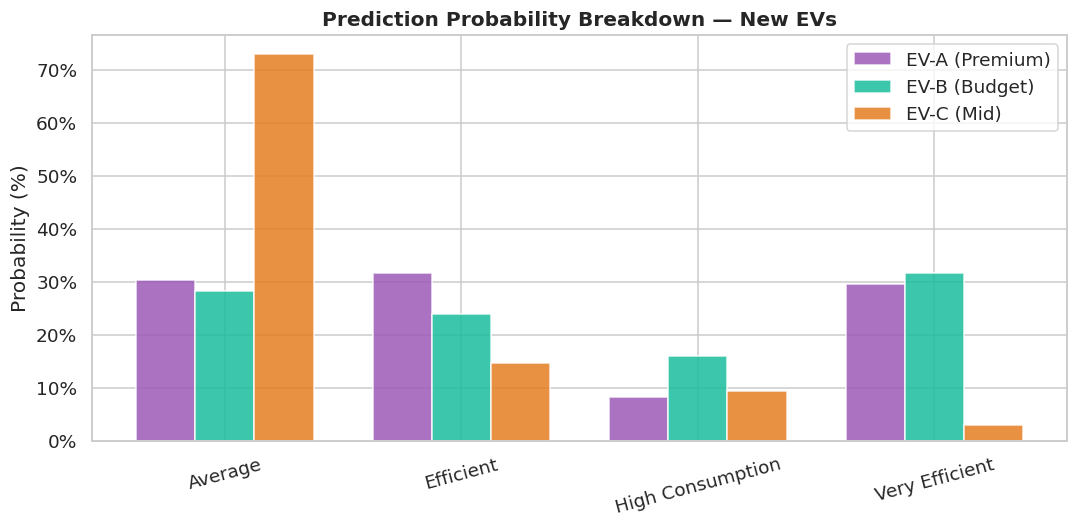

In [27]:
# ── Probability breakdown for new EVs ─────────────────────────────────────────
labels = ['EV-A (Premium)', 'EV-B (Budget)', 'EV-C (Mid)']
x = np.arange(len(le.classes_))
width = 0.25
bar_colors = ['#9b59b6', '#1abc9c', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, proba, color) in enumerate(zip(labels, pred_proba, bar_colors)):
    bars = ax.bar(x + (i-1)*width, proba*100, width,
                  label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(le.classes_, rotation=15)
ax.set_ylabel('Probability (%)')
ax.set_title('Prediction Probability Breakdown — New EVs', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

---
## 10. 💾 Save & Export

In [28]:
# ── Save final model & label encoder ──────────────────────────────────────────
joblib.dump(final_model, 'ev_rating_model.pkl')
joblib.dump(le,           'label_encoder.pkl')

print("✅ Saved: ev_rating_model.pkl")
print("✅ Saved: label_encoder.pkl")

# ── Save predictions to CSV ───────────────────────────────────────────────────
test_results = X_test.copy()
test_results['Actual']    = le.inverse_transform(y_test)
test_results['Predicted'] = le.inverse_transform(y_final_pred)
test_results['Correct']   = test_results['Actual'] == test_results['Predicted']
test_results.to_csv('ev_test_predictions.csv', index=False)
print("✅ Saved: ev_test_predictions.csv")

✅ Saved: ev_rating_model.pkl
✅ Saved: label_encoder.pkl
✅ Saved: ev_test_predictions.csv


In [29]:
# ── Reload model and verify ────────────────────────────────────────────────────
loaded_model = joblib.load('ev_rating_model.pkl')
loaded_le    = joblib.load('label_encoder.pkl')

verify_preds = loaded_model.predict(X_test[NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES])
verify_acc   = accuracy_score(y_test, verify_preds)

print(f"🔍 Reload verification — Accuracy: {verify_acc:.4f}")
assert np.array_equal(verify_preds, y_final_pred), "⚠️ Mismatch after reload!"
print("✅ Model reload verified — predictions match!")

🔍 Reload verification — Accuracy: 0.9524
✅ Model reload verified — predictions match!


In [30]:
# ── 📋 Project Summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("       ⚡ EV Energy Rating Prediction — Summary")
print("=" * 60)
print(f"  Dataset           : {len(df)} EVs × {len(df.columns)} features")
print(f"  Target classes    : {list(le.classes_)}")
print(f"  Train/Test split  : {len(X_train)} / {len(X_test)}")
print(f"  Features used     : {len(NUMERIC_FEATURES + BINARY_FEATURES + NOMINAL_FEATURES)} ({len(NUMERIC_FEATURES)} numeric, {len(BINARY_FEATURES)} binary, {len(NOMINAL_FEATURES)} nominal)")
print(f"  Engineered feats  : Speed_Range_Ratio, Charge_Efficiency, Value_Score, Perf_Index")
print()
print("  Model Leaderboard:")
for _, row in res_df.iterrows():
    marker = '🏆' if row['Model'] == BEST_MODEL_NAME else '  '
    print(f"  {marker}  {row['Model']:<25}  Test Acc: {row['Test Acc']:.4f}")
print()
print(f"  Final Model       : Random Forest (Tuned GridSearchCV)")
print(f"  Final Test Acc    : {final_acc:.4f}  ({final_acc*100:.1f}%)")
print("=" * 60)

       ⚡ EV Energy Rating Prediction — Summary
  Dataset           : 103 EVs × 16 features
  Target classes    : [np.str_('Average'), np.str_('Efficient'), np.str_('High Consumption'), np.str_('Very Efficient')]
  Train/Test split  : 82 / 21
  Features used     : 17 (12 numeric, 1 binary, 4 nominal)
  Engineered feats  : Speed_Range_Ratio, Charge_Efficiency, Value_Score, Perf_Index

  Model Leaderboard:
  🏆  Gradient Boosting          Test Acc: 1.0000
      XGBoost                    Test Acc: 1.0000
      Random Forest              Test Acc: 0.9524
      KNN                        Test Acc: 0.7143
      Logistic Regression        Test Acc: 0.6667
      SVM                        Test Acc: 0.5714

  Final Model       : Random Forest (Tuned GridSearchCV)
  Final Test Acc    : 0.9524  (95.2%)
